In [60]:
import pandas as pd

from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

import matplotlib.pyplot as plt

In [61]:
X_train = pd.read_csv("C:/Users/slmkc/Downloads/PhaseI/Churn_model/data/processed/X_train.csv")

Y_train = pd.read_csv("C:/Users/slmkc/Downloads/PhaseI/Churn_model/data/processed/Y_train.csv")["Churn"]

In [62]:
print(X_train.shape, Y_train.shape)

print("Churn rate:", round(Y_train.mean(), 4))

(5634, 27) (5634,)
Churn rate: 0.2654


In [63]:
dummy = DummyClassifier(strategy = "most_frequent")

dummy.fit(X_train, Y_train)

pred = dummy.predict(X_train)

In [64]:
print("Accuracy:",round(accuracy_score(Y_train, pred), 3))

print("Precision:", round(precision_score(Y_train, pred, zero_division = 0), 3))

print("Recall:", round(recall_score(Y_train, pred), 3))

print("F1:", round(f1_score(Y_train, pred), 3))

Accuracy: 0.735
Precision: 0.0
Recall: 0.0
F1: 0.0


In [71]:
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter = 1000, class_weight = "balanced")), 

    "Decision Tree": DecisionTreeClassifier(max_depth = 5, class_weight = "balanced", random_state = 42),

    "Random Forest": RandomForestClassifier(n_estimators = 200, max_depth = 8, min_samples_leaf = 5, class_weight = "balanced", random_state = 42),

    "Gradient Boosting": HistGradientBoostingClassifier(max_iter = 100, learning_rate = 0.05, class_weight = "balanced", random_state = 42),

}

In [72]:
rows = []

for name, model in models.items():
    scores = cross_validate(model, X_train, Y_train, cv = cv, scoring = scoring)
    rows.append({
        "model": name,
        "accuracy": scores["test_accuracy"].mean(),
        "precision": scores["test_precision"].mean(),
        "recall": scores["test_recall"].mean(),
        "f1": scores["test_f1"].mean(),
        "roc_auc": scores["test_roc_auc"].mean(),
        "roc_auc_std": scores["test_roc_auc"].std(),
    })
    print(name)

results = pd.DataFrame(rows).round(3)
results.sort_values("roc_auc", ascending = False)

Logistic Regression
Decision Tree
Random Forest
Gradient Boosting


,model,accuracy,precision,recall,f1,roc_auc,roc_auc_std
0,Logistic Regression,0.749,0.518,0.798,0.628,0.846,0.012
2,Random Forest,0.770,0.548,0.754,0.635,0.846,0.011
3,Gradient Boosting,0.763,0.537,0.763,0.630,0.843,0.011
1,Decision Tree,0.730,0.497,0.809,0.615,0.825,0.013


In [73]:
for depth in [2, 5, 10, None]:
    tree = DecisionTreeClassifier(max_depth = depth, class_weight = "balanced", random_state = 42)
    
    s = cross_validate(tree, X_train, Y_train, cv = cv, scoring = "roc_auc", return_train_score = True)
    
    print("max_depth =", depth, "| Train AUC:", round(s["train_score"].mean(), 3), "| validation AUC:", round(s["test_score"].mean(), 3))

max_depth = 2 | Train AUC: 0.756 | validation AUC: 0.75
max_depth = 5 | Train AUC: 0.852 | validation AUC: 0.825
max_depth = 10 | Train AUC: 0.945 | validation AUC: 0.748
max_depth = None | Train AUC: 1.0 | validation AUC: 0.651


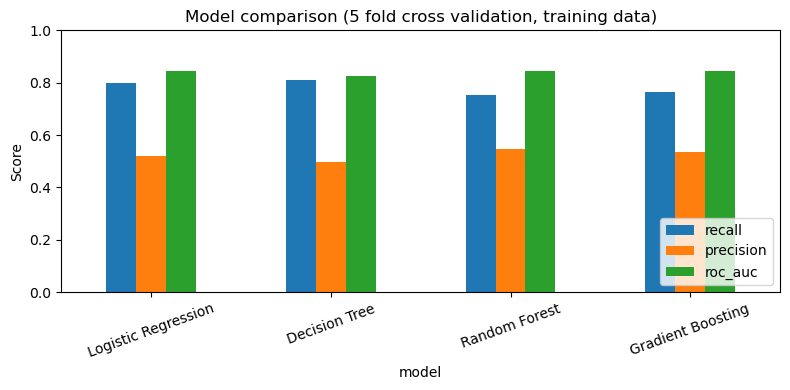

In [74]:
results.set_index("model")[["recall", "precision", "roc_auc"]].plot(kind = "bar", figsize = (8,4))

plt.title("Model comparison (5 fold cross validation, training data)")

plt.ylabel("Score")
plt.xticks(rotation = 20)
plt.ylim(0,1)

plt.legend(loc = "lower right")
plt.tight_layout()
plt.show()

In [75]:
result.to_csv("C:/Users/slmkc/Downloads/PhaseI/Churn_model/reports/model_comparison.csv", index = False)

In [76]:
four_new = ["num_addons", "is_first_year", "monthly_echeck", "lives_alone"]
X_train_raw = X_train.drop(columns = four_new)

lr = models["Logistic Regression"]
with_new = cross_validate(lr, X_train, Y_train, cv =cv , scoring = "roc_auc")["test_score"]
without_new = cross_validate(lr, X_train_raw, Y_train, cv = cv, scoring = "roc_auc")["test_score"]

print("With the 4 new feature:", round(with_new.mean(), 4))
print("Without the 4 new feature:", round(without_new.mean(), 4))

With the 4 new feature: 0.8459
Without the 4 new feature: 0.846
